Exploratory Data Analysis of the Pima Indians Diabetes dataset.

The datasets includes the following features:
    
    Pregnancies
    Glucose
    BloodPressure
    SkinThickness
    Insulin
    BMI
    DiabetesPedigreeFunction
    Age
    
The target "Outcome" has 2 classes namely 0 (no diabetes) and 1 (diabetes).

# Exploratory Data Analysis (EDA) - Pima Indians Diabetes Dataset

## Tổng quan
Phân tích chi tiết dataset về bệnh tiểu đường của dân tộc Pima giúp chúng ta hiểu các đặc điểm và mối liên hệ trong dữ liệu y tế. Mục đích là chuẩn bị dữ liệu và khám phá các mô hình có thể dự đoán bệnh tiểu đường.

# **Introduction**

## 1. Load Data và Xem Tổng Quan

Phân tích chi tiết dataset về bệnh tiểu đường của dân tộc Pima giúp chúng ta hiểu các đặc điểm và mối liên hệ trong dữ liệu y tế. Mục đích là chuẩn bị dữ liệu và khám phá các mô hình có thể dự đoán bệnh tiểu đường.

Bước đầu tiên là tải dữ liệu từ tệp CSV và kiểm tra hình dạng (số hàng, số cột) cũng như các dòng dữ liệu đầu tiên để hiểu cấu trúc dữ liệu.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Thiết lập style cho matplotlib và seaborn
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load dữ liệu với tên cột
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv('Data/pima-indians-diabetes.csv', header=None, names=column_names)

print("=" * 60)
print("TỔNG QUAN DỮ LIỆU")
print("=" * 60)
print(f"\nHình dạng dữ liệu (rows, columns): {df.shape}")
print(f"\nDữ liệu 5 hàng đầu tiên:")
print(df.head())

TỔNG QUAN DỮ LIỆU

Hình dạng dữ liệu (rows, columns): (768, 9)

Dữ liệu 5 hàng đầu tiên:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


# **A first look and non-graphical EDA**

In [13]:
print("\n" + "=" * 60)
print("THÔNG TIN DỮ LIỆU")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("THỐNG KÊ MÔ TẢ (Describe)")
print("=" * 60)
print(df.describe())


THÔNG TIN DỮ LIỆU
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

THỐNG KÊ MÔ TẢ (Describe)
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105

More details: the types of variables

In [14]:
print("\n" + "=" * 60)
print("PHÁT HIỆN MISSING VALUES ẨN (Giá trị 0)")
print("=" * 60)

# Các cột không nên có giá trị 0
columns_zero_invalid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

missing_values_analysis = pd.DataFrame({
    'Column': columns_zero_invalid,
    'Count_Zeros': [df[col][df[col] == 0].shape[0] for col in columns_zero_invalid]
})

missing_values_analysis['Percentage'] = (missing_values_analysis['Count_Zeros'] / len(df)) * 100
print("\n" + missing_values_analysis.to_string(index=False))

# Thay thế 0 bằng NaN để xử lý dễ dàng hơn
df_clean = df.copy()
for col in columns_zero_invalid:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print(f"\n- Tổng số missing values sau khi thay thế 0:")
print(df_clean[columns_zero_invalid].isnull().sum())

# Impute missing values bằng median
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
df_clean[columns_zero_invalid] = imputer.fit_transform(df_clean[columns_zero_invalid])

print(f"\n- Sau khi impute bằng median:")
print(f"Missing values còn lại: {df_clean.isnull().sum().sum()}")


PHÁT HIỆN MISSING VALUES ẨN (Giá trị 0)

       Column  Count_Zeros  Percentage
      Glucose            5    0.651042
BloodPressure           35    4.557292
SkinThickness          227   29.557292
      Insulin          374   48.697917
          BMI           11    1.432292

- Tổng số missing values sau khi thay thế 0:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

- Sau khi impute bằng median:
Missing values còn lại: 0


**Các thống kê của các biến là gì?**

## Correlation Between Variables

In [15]:
df_clean.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218937,0.192615,0.419451,0.231049,0.137327,0.266909,0.492782
BloodPressure,0.208615,0.218937,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915,0.165723
SkinThickness,0.081770,0.192615,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107,0.214873
Insulin,0.025047,0.419451,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101,0.203790
BMI,0.021559,0.231049,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597,0.312038
DiabetesPedigreeFunction,-0.033523,0.137327,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.165723,0.214873,0.203790,0.312038,0.173844,0.238356,1.000000


# **Graphical EDA**

## **Histograms and Distributions**

Biểu đồ histogram giúp chúng ta hiểu rõ:
- **Phân phối** của từng biến (chuẩn, lệch trái/phải, đa phương thức)
- **Khoảng phổ biến** của giá trị
- **Tần suất** xuất hiện của các giá trị

Chúng ta sẽ vẽ histogram cho tất cả các đặc trưng để xác định các mô hình và bất thường.

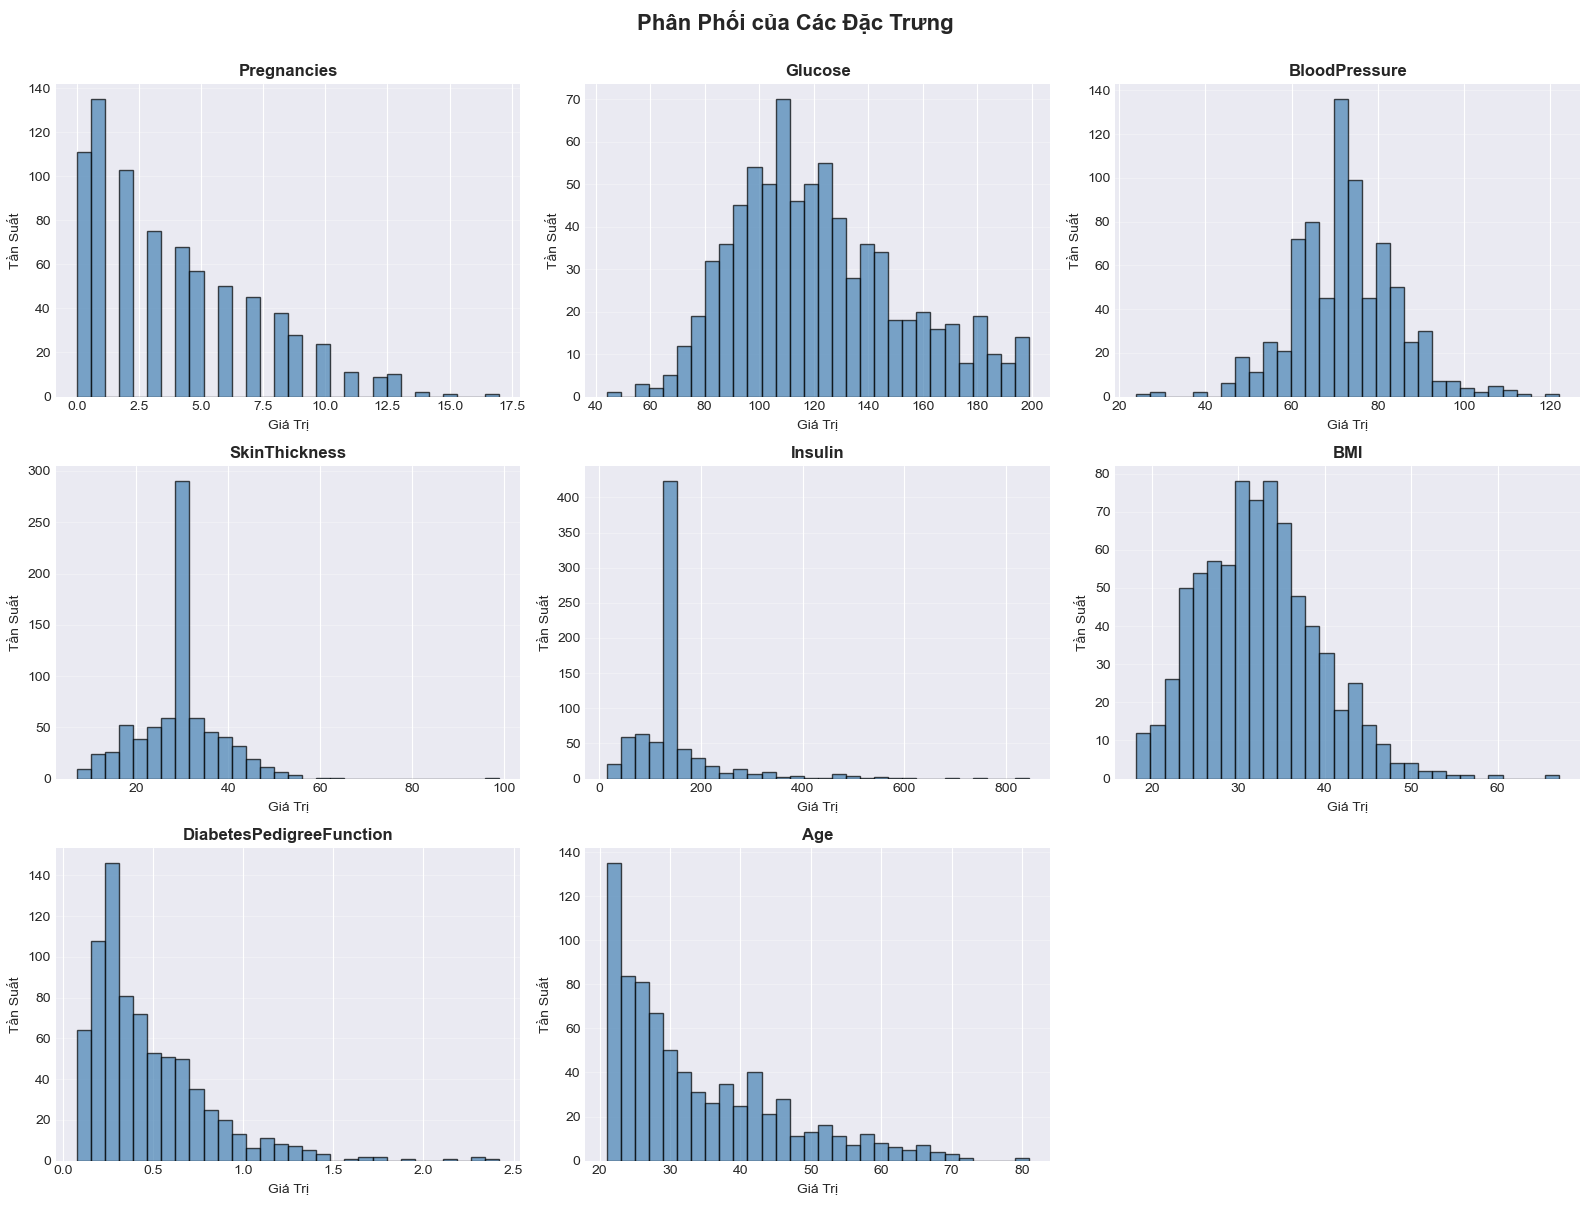


 Nhận xét về phân phối:
Pregnancies         : Skewness = 0.900 (Lệch phải)
Glucose             : Skewness = 0.535 (Lệch phải)
BloodPressure       : Skewness = 0.142 (Gần như chuẩn)
SkinThickness       : Skewness = 0.836 (Lệch phải)
Insulin             : Skewness = 3.373 (Lệch phải)
BMI                 : Skewness = 0.598 (Lệch phải)
DiabetesPedigreeFunction: Skewness = 1.916 (Lệch phải)
Age                 : Skewness = 1.127 (Lệch phải)


In [16]:
# Histogram cho tất cả các cột đặc trưng
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Phân Phối của Các Đặc Trưng', fontsize=16, fontweight='bold', y=1.00)

features = df_clean.columns[:-1]  # Loại bỏ cột Outcome

for idx, (ax, feature) in enumerate(zip(axes.flat, features)):
    ax.hist(df_clean[feature], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{feature}', fontweight='bold')
    ax.set_xlabel('Giá Trị')
    ax.set_ylabel('Tần Suất')
    ax.grid(axis='y', alpha=0.3)

# Xóa subplot trống cuối cùng
axes.flat[-1].remove()

plt.tight_layout()
plt.show()

print("\n Nhận xét về phân phối:")
for feature in features:
    skewness = stats.skew(df_clean[feature])
    print(f"{feature:20s}: Skewness = {skewness:.3f}", end="")
    if abs(skewness) < 0.5:
        print(" (Gần như chuẩn)")
    elif skewness > 0:
        print(" (Lệch phải)")
    else:
        print(" (Lệch trái)")

## **Are the classes (Outcome) balanced?**


OUTCOME DISTRIBUTION
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome = 0 (No diabetes): 500 (65.1%)
Outcome = 1 (Diabetes): 268 (34.9%)


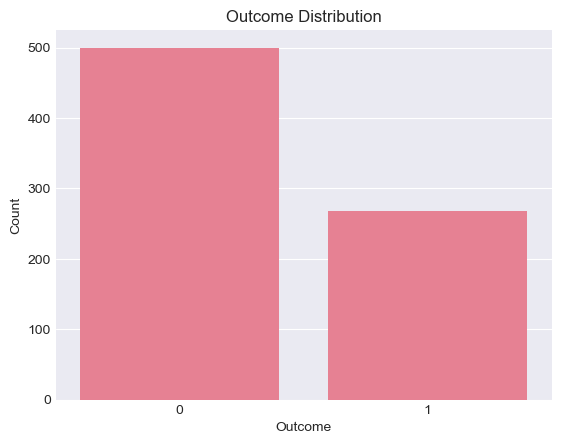

In [17]:
# Check Outcome balance
print("\n" + "=" * 60)
print("OUTCOME DISTRIBUTION")
print("=" * 60)
outcome_counts = df['Outcome'].value_counts()
print(outcome_counts)
print(f"\nOutcome = 0 (No diabetes): {outcome_counts[0]} ({outcome_counts[0]/len(df)*100:.1f}%)")
print(f"Outcome = 1 (Diabetes): {outcome_counts[1]} ({outcome_counts[1]/len(df)*100:.1f}%)")

# Visualize with seaborn
import matplotlib.pyplot as plt
sns.countplot(x=df['Outcome'])
plt.title('Outcome Distribution')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

### Kết luận:

- Classes không cân bằng
- Số lượng người không mắc bệnh tiểu đường nhiều hơn số người mắc bệnh
- Có thể cần sử dụng các metrics phù hợp hoặc techniques để xử lý imbalance

## **Boxplots and Outliers**

Boxplot hiển thị:
- **Hộp (Box)**: chứa 50% dữ liệu ở giữa (từ Q1 đến Q3)
- **Đường trong hộp**: là median (Q2)
- **Râu (Whiskers)**: khoảng từ Q1-1.5×IQR đến Q3+1.5×IQR
- **Điểm ngoài**: là outliers

Phương pháp **IQR (Interquartile Range)**: Nếu một giá trị nằm ngoài khoảng [Q1-1.5×IQR, Q3+1.5×IQR] thì nó là outlier.

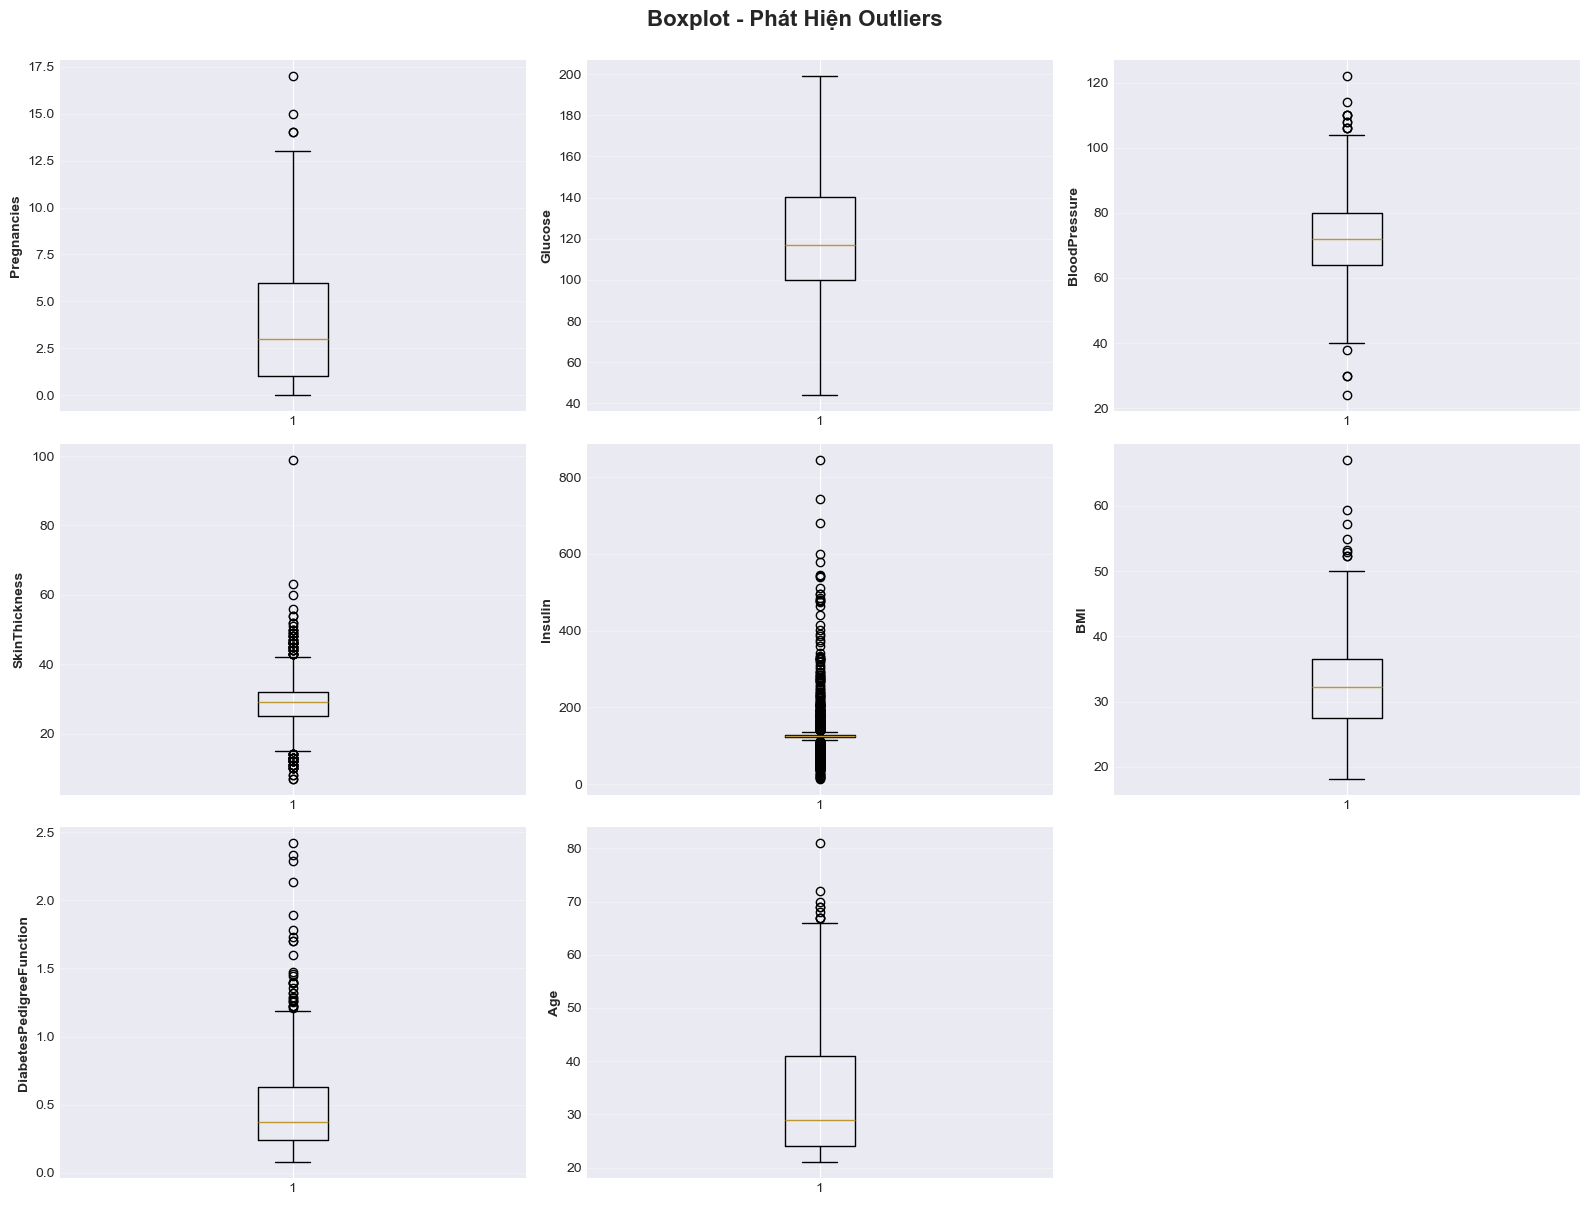


PHÁT HIỆN OUTLIERS BẰNG PHƯƠNG PHÁP IQR

Feature              Outliers   Lower Bound  Upper Bound 
------------------------------------------------------
Pregnancies          4          -6.50        13.50       
Glucose              0          39.00        201.00      
BloodPressure        14         40.00        104.00      
SkinThickness        87         14.50        42.50       
Insulin              346        112.88       135.88      
BMI                  8          13.85        50.25       
DiabetesPedigreeFunction 29         -0.33        1.20        
Age                  9          -1.50        66.50       


In [18]:
# Boxplot cho các đặc trưng
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Boxplot - Phát Hiện Outliers', fontsize=16, fontweight='bold', y=1.00)

for idx, (ax, feature) in enumerate(zip(axes.flat, features)):
    ax.boxplot(df_clean[feature], vert=True)
    ax.set_ylabel(feature, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

# Xóa subplot trống
axes.flat[-1].remove()

plt.tight_layout()
plt.show()

# Đếm số lượng outliers theo phương pháp IQR
print("\n" + "=" * 60)
print("PHÁT HIỆN OUTLIERS BẰNG PHƯƠNG PHÁP IQR")
print("=" * 60)

def count_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print(f"\n{'Feature':<20} {'Outliers':<10} {'Lower Bound':<12} {'Upper Bound':<12}")
print("-" * 54)

for feature in features:
    outlier_count, lb, ub = count_outliers_iqr(df_clean[feature])
    print(f"{feature:<20} {outlier_count:<10} {lb:<12.2f} {ub:<12.2f}")

## **Correlation Heatmap**

Chúng ta có thể trực quan hóa mối tương quan bằng một heatmap.

Heatmap: một biểu diễn đồ họa hai chiều của dữ liệu trong đó các giá trị riêng lẻ trong ma trận được biểu diễn bằng các màu sắc

## **Comparison between Outcome Groups**

**Outcome = 0**: Không bị bệnh tiểu đường  
**Outcome = 1**: Bị bệnh tiểu đường

Bằng cách so sánh phân phối các đặc trưng giữa hai nhóm, chúng ta có thể:
- Xác định những đặc trưng nào có **sự khác biệt rõ ràng** giữa bệnh nhân và người khỏe mạnh
- Tìm ra **các đặc trưng quan trọng** cho dự đoán
- Hiểu về **bản chất bệnh** thông qua các chỉ số y tế

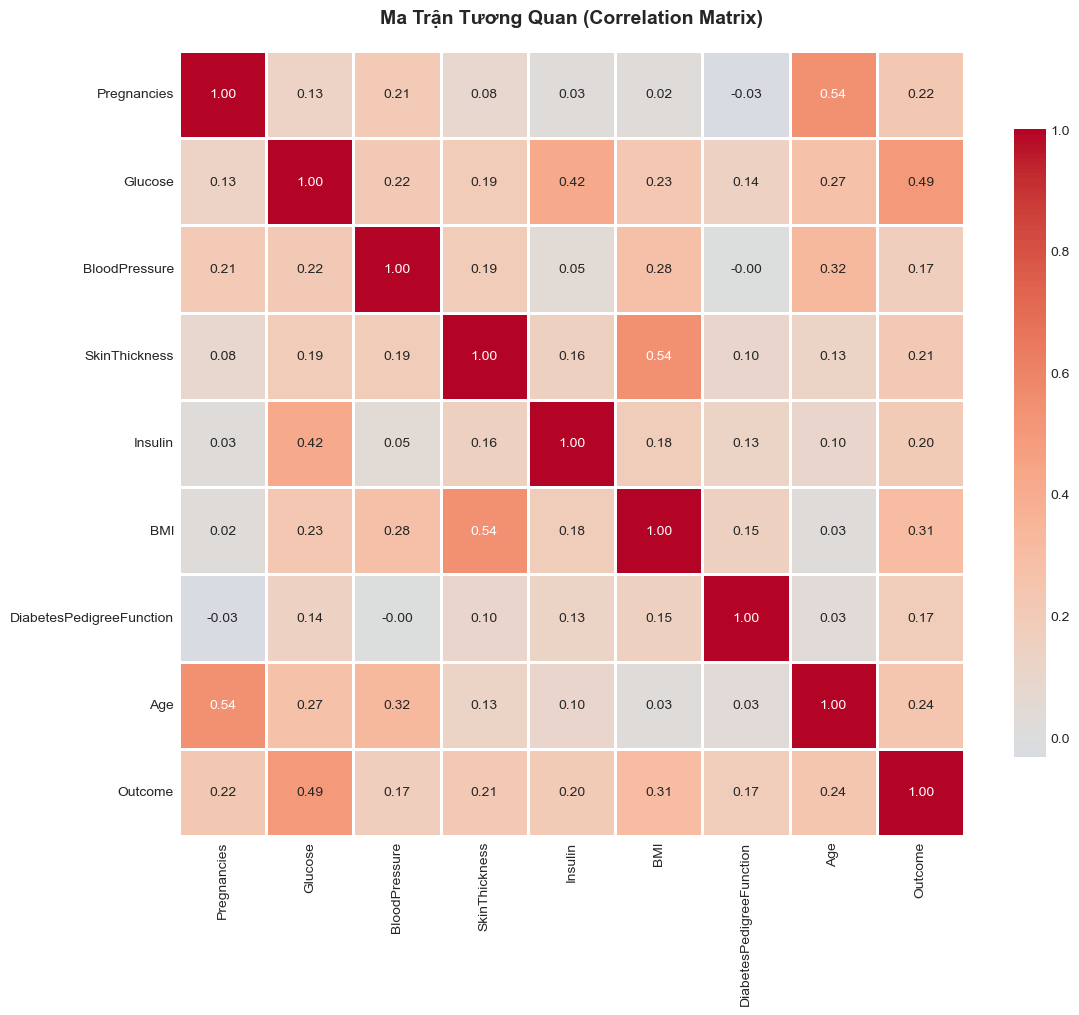


TƯƠNG QUAN VỚI OUTCOME (Biến mục tiêu)
Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64

CÁC TƯƠNG QUAN MẠNH GIỮA CÁC ĐẶC TRƯNG (|corr| > 0.5)
Pregnancies               <-> Age                       : 0.5443
SkinThickness             <-> BMI                       : 0.5432


In [19]:
# Tính ma trận tương quan
correlation_matrix = df_clean.corr()

# Tạo heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Ma Trận Tương Quan (Correlation Matrix)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# In ra các tương quan mạnh (> 0.5 hoặc < -0.5) với Outcome
print("\n" + "=" * 60)
print("TƯƠNG QUAN VỚI OUTCOME (Biến mục tiêu)")
print("=" * 60)
outcome_corr = correlation_matrix['Outcome'].sort_values(ascending=False)
print(outcome_corr)

print("\n" + "=" * 60)
print("CÁC TƯƠNG QUAN MẠNH GIỮA CÁC ĐẶC TRƯNG (|corr| > 0.5)")
print("=" * 60)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.5:
            print(f"{correlation_matrix.columns[i]:<25} <-> {correlation_matrix.columns[j]:<25} : {correlation_matrix.iloc[i, j]:.4f}")

In [20]:
# Phân tách dữ liệu theo Outcome
outcome_0 = df_clean[df_clean['Outcome'] == 0]
outcome_1 = df_clean[df_clean['Outcome'] == 1]

print("\n" + "=" * 60)
print("THỐNG KÊ MÔ TẢ THEO NHÓM OUTCOME")
print("=" * 60)
print(f"\nOutcome = 0 (Không bị bệnh tiểu đường): {len(outcome_0)} mẫu ({len(outcome_0)/len(df_clean)*100:.1f}%)")
print(f"Outcome = 1 (Bị bệnh tiểu đường):       {len(outcome_1)} mẫu ({len(outcome_1)/len(df_clean)*100:.1f}%)")

print("\n" + "=" * 60)
print("THỐNG KÊ CHI TIẾT - OUTCOME = 0")
print("=" * 60)
print(outcome_0[features].describe())

print("\n" + "=" * 60)
print("THỐNG KÊ CHI TIẾT - OUTCOME = 1")
print("=" * 60)
print(outcome_1[features].describe())


THỐNG KÊ MÔ TẢ THEO NHÓM OUTCOME

Outcome = 0 (Không bị bệnh tiểu đường): 500 mẫu (65.1%)
Outcome = 1 (Bị bệnh tiểu đường):       268 mẫu (34.9%)

THỐNG KÊ CHI TIẾT - OUTCOME = 0
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   500.000000  500.000000     500.000000     500.000000  500.000000   
mean      3.298000  110.682000      70.920000      27.726000  127.792000   
std       3.017185   24.707201      11.929385       8.552966   74.447469   
min       0.000000   44.000000      24.000000       7.000000   15.000000   
25%       1.000000   93.000000      63.500000      22.000000   95.000000   
50%       2.000000  107.500000      72.000000      29.000000  125.000000   
75%       5.000000  125.000000      78.000000      31.000000  125.000000   
max      13.000000  197.000000     122.000000      60.000000  744.000000   

              BMI  DiabetesPedigreeFunction         Age  
count  500.000000                500.000000  500.000000  
mean    30.885600  

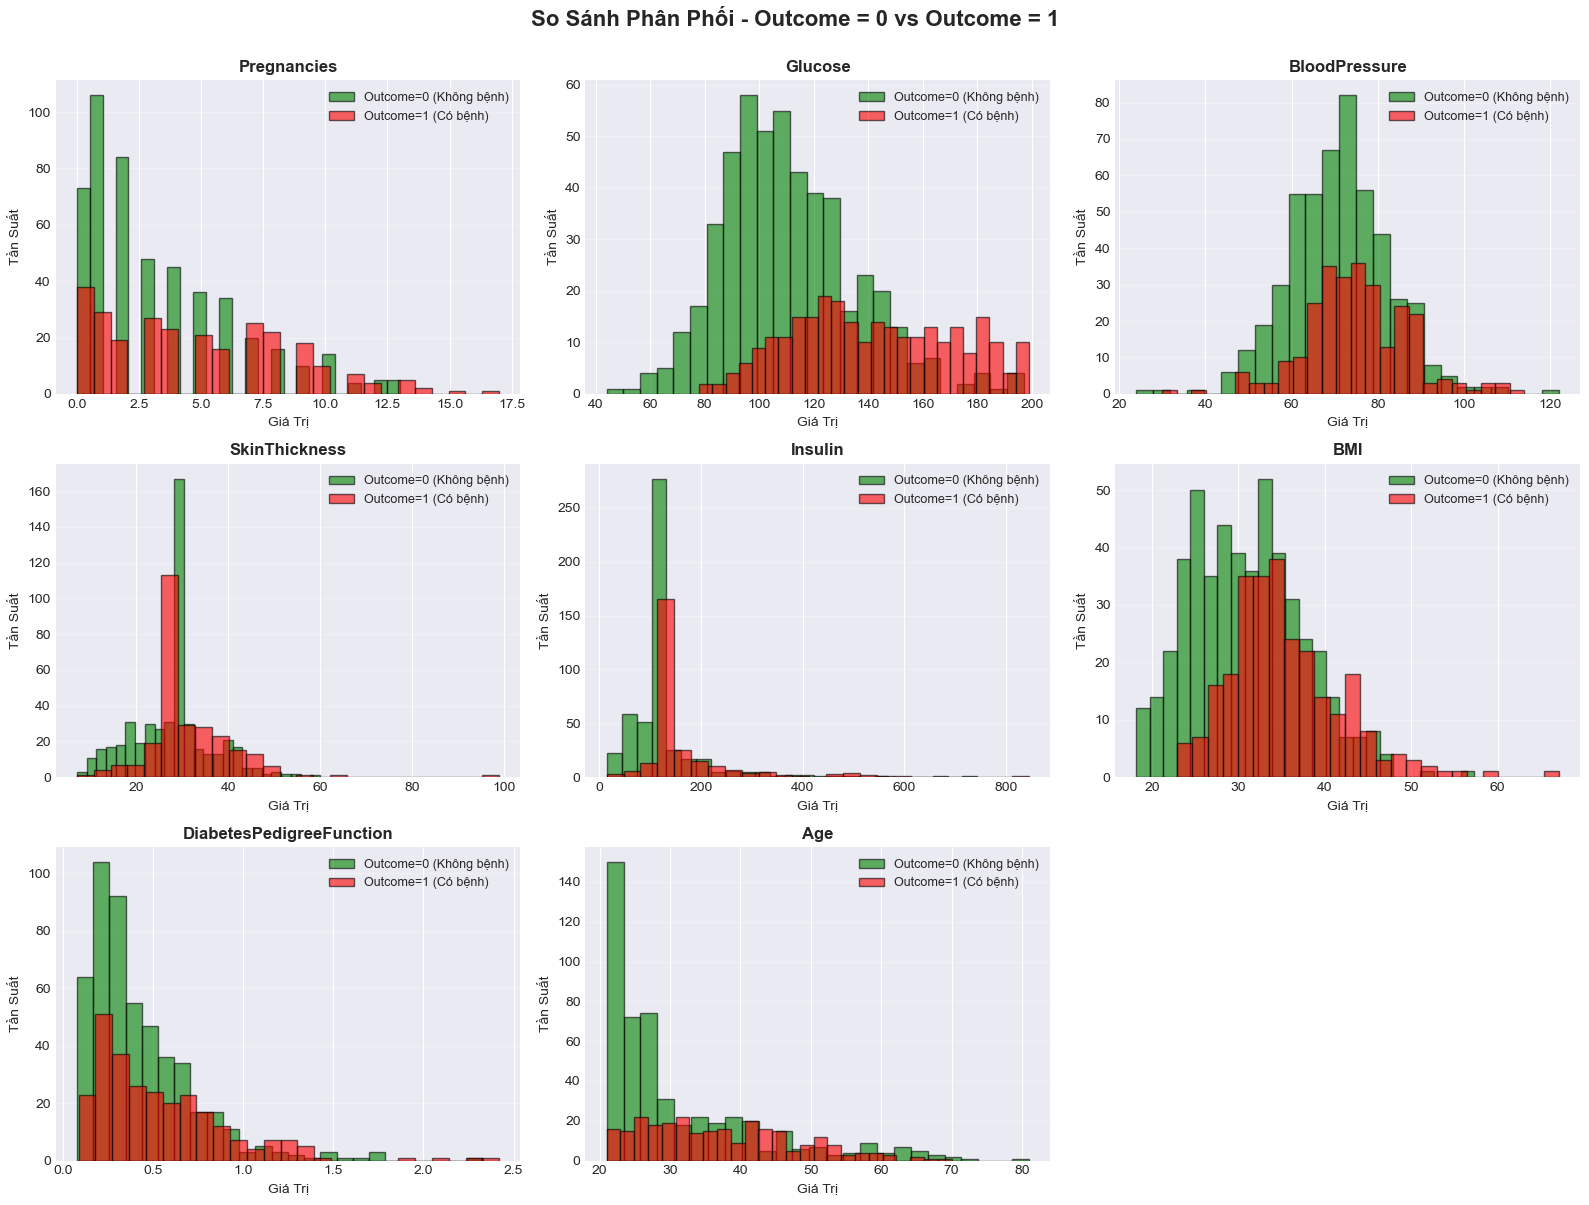

In [21]:
# Vẽ histogram so sánh giữa hai nhóm Outcome
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('So Sánh Phân Phối - Outcome = 0 vs Outcome = 1', fontsize=16, fontweight='bold', y=1.00)

for idx, (ax, feature) in enumerate(zip(axes.flat, features)):
    ax.hist(outcome_0[feature], bins=25, alpha=0.6, label='Outcome=0 (Không bệnh)', color='green', edgecolor='black')
    ax.hist(outcome_1[feature], bins=25, alpha=0.6, label='Outcome=1 (Có bệnh)', color='red', edgecolor='black')
    ax.set_title(f'{feature}', fontweight='bold')
    ax.set_xlabel('Giá Trị')
    ax.set_ylabel('Tần Suất')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

axes.flat[-1].remove()
plt.tight_layout()
plt.show()

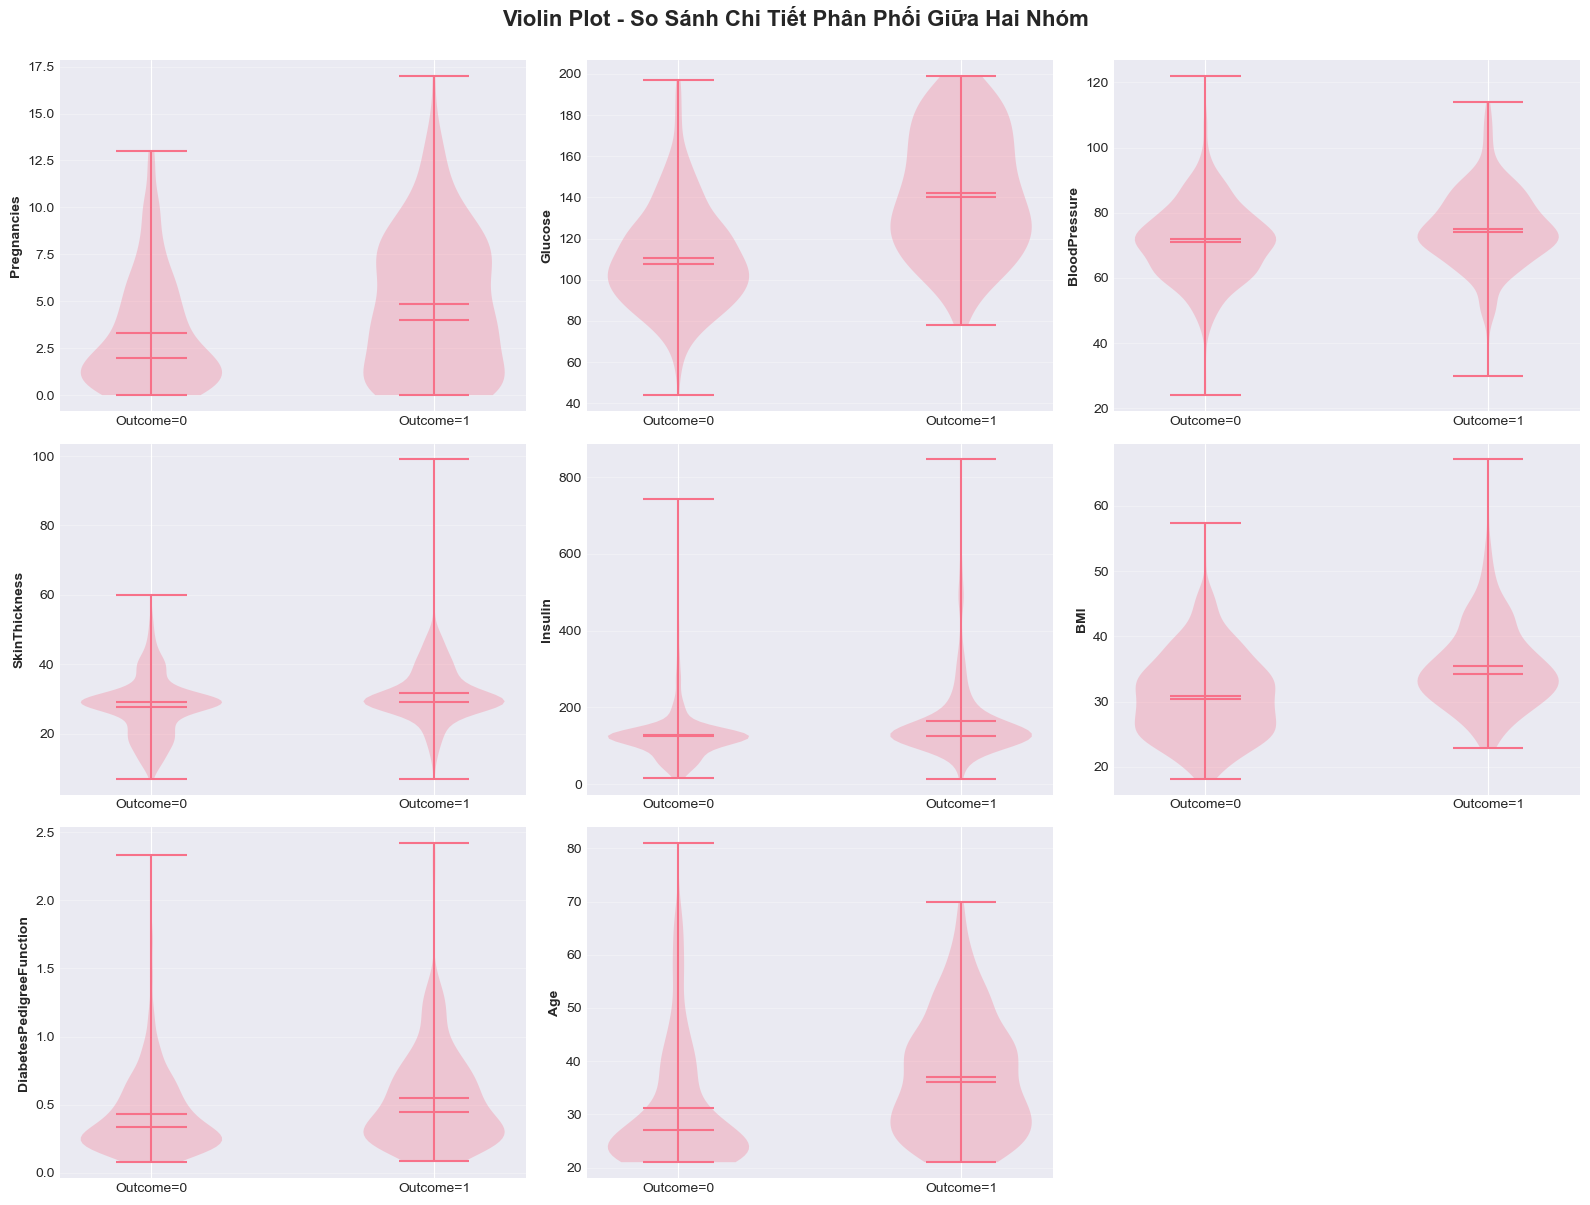


T-TEST: SỰ KHÁC BIỆT GIỮA HAI NHÓM OUTCOME

Feature              t-statistic     p-value         Kết luận            
----------------------------------------------------------------------
Pregnancies          -6.2984         0.000000        Có khác biệt        
Glucose              -15.6738        0.000000        Có khác biệt        
BloodPressure        -4.6510         0.000004        Có khác biệt        
SkinThickness        -6.0892         0.000000        Có khác biệt        
Insulin              -5.7611         0.000000        Có khác biệt        
BMI                  -9.0901         0.000000        Có khác biệt        
DiabetesPedigreeFunction -4.8858         0.000001        Có khác biệt        
Age                  -6.7927         0.000000        Có khác biệt        


In [22]:
# Vẽ violin plot để so sánh phân phối chi tiết hơn
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Violin Plot - So Sánh Chi Tiết Phân Phối Giữa Hai Nhóm', fontsize=16, fontweight='bold', y=1.00)

for idx, (ax, feature) in enumerate(zip(axes.flat, features)):
    data_to_plot = [outcome_0[feature].values, outcome_1[feature].values]
    parts = ax.violinplot(data_to_plot, positions=[0, 1], showmeans=True, showmedians=True)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Outcome=0', 'Outcome=1'])
    ax.set_ylabel(feature, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

axes.flat[-1].remove()
plt.tight_layout()
plt.show()

# Kiểm tra sự khác biệt giữa hai nhóm bằng t-test
print("\n" + "=" * 60)
print("T-TEST: SỰ KHÁC BIỆT GIỮA HAI NHÓM OUTCOME")
print("=" * 60)
print(f"\n{'Feature':<20} {'t-statistic':<15} {'p-value':<15} {'Kết luận':<20}")
print("-" * 70)

for feature in features:
    t_stat, p_val = stats.ttest_ind(outcome_0[feature], outcome_1[feature])
    significance = "Có khác biệt" if p_val < 0.05 else "Không khác biệt"
    print(f"{feature:<20} {t_stat:<15.4f} {p_val:<15.6f} {significance:<20}")

## Conclusion

### Những điểm chính từ phân tích:

1. **Dataset Balance**: Dữ liệu không cân bằng, với số người không mắc bệnh tiểu đường (0) nhiều hơn số người mắc bệnh tiểu đường (1)

2. **Missing Values**: Các giá trị bằng 0 trong các cột y tế là những missing values ẩn đã được xử lý bằng imputation với median

3. **Distributions**: Nhiều đặc trưng có phân phối lệch phải (right-skewed), đặc biệt là Insulin và DiabetesPedigreeFunction

4. **Outliers**: Một số đặc trưng có outliers, cần cân nhắc có nên loại bỏ chúng trong quá trình modeling hay không

5. **Correlations**: 
   - Glucose, BMI, Age có mối tương quan mạnh với Outcome
   - Một số đặc trưng có mối tương quan cao với nhau, multicollinearity có thể tồn tại

6. **Differences between groups**: Nhóm bệnh tiểu đường (Outcome=1) có giá trị cao hơn hầu hết các chỉ số so với nhóm không mắc bệnh (Outcome=0)

**Bước tiếp theo**: Normalize dữ liệu, handle imbalance, build predictive model.